In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

In [8]:
df.shape

(7043, 21)

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
blank_total_charges = (df["TotalCharges"].str.strip() == "").sum()

print("Blank TotalCharges values:", blank_total_charges)

Blank TotalCharges values: 11


In [15]:
df.loc[df["TotalCharges"].str.strip() == "", "tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

In [16]:
df["customerID"].duplicated().sum()

np.int64(0)

In [17]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# Data Understanding

## Dataset Overview

The dataset used for this project is the IBM Telco Customer Churn dataset. It contains customer demographic information, subscribed services, contract details, billing information, and a binary churn outcome.

The dataset contains:

- **7,043 customer records**
- **21 columns**
- **20 predictor/customer attributes**
- **1 target variable: `Churn`**

## Initial Data Quality Findings

The initial inspection revealed the following:

- No duplicate `customerID` values were found.
- No actual `NaN` values were detected using `isnull()`.
- `TotalCharges` was loaded as a string rather than a numerical data type.
- 11 records contained blank `TotalCharges` values.
- All 11 of these records had `tenure = 0`.
- The blank `TotalCharges` values will be handled during the preprocessing stage rather than modifying the raw dataset.

## Target Variable

The target variable is `Churn`, which contains two classes:

- `No`: 5,174 customers (73.46%)
- `Yes`: 1,869 customers (26.54%)

The target variable is therefore moderately imbalanced, with non-churned customers representing the majority class.

Because of this class imbalance, model evaluation will not rely on accuracy alone. Precision, recall, F1-score, ROC-AUC, and the confusion matrix will also be considered.

## Important Analytical Consideration

The dataset is a customer-level snapshot/sample rather than a longitudinal experiment. Therefore, relationships identified during analysis should be interpreted as associations rather than proof that a particular factor directly causes customer churn.

In [19]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtecti

C:\Users\INTEL\AppData\Local\Temp\ipykernel_15616\2658559855.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


In [25]:
categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "Churn"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport:
TechSupport
No   

In [26]:
columns_to_check = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

--- TechSupport ---
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

--- StreamingTV ---
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

-

In [27]:
columns_to_check = [
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

--- TechSupport ---
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

--- StreamingTV ---
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

--- StreamingMovies ---
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


In [28]:
columns_to_check = [
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- PaperlessBilling ---
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [29]:
print("Tenure range:", df["tenure"].min(), "to", df["tenure"].max())
print("Monthly Charges range:", df["MonthlyCharges"].min(), "to", df["MonthlyCharges"].max())

Tenure range: 0 to 72
Monthly Charges range: 18.25 to 118.75


In [30]:
print("Negative tenure:", (df["tenure"] < 0).sum())
print("Negative MonthlyCharges:", (df["MonthlyCharges"] < 0).sum())

Negative tenure: 0
Negative MonthlyCharges: 0


In [31]:
for column in categorical_columns:
    blank_count = df[column].astype(str).str.strip().eq("").sum()
    if blank_count > 0:
        print(f"{column}: {blank_count} blank values")

# Data Understanding — Summary

The initial investigation of the IBM Telco Customer Churn dataset identified 7,043 customer records and 21 columns.

## Key Findings

1. The dataset contains 20 customer attributes and one binary target variable, `Churn`.

2. No duplicate `customerID` values were identified.

3. No actual `NaN` values were detected using the standard Pandas missing-value check.

4. The `TotalCharges` column was loaded as a string rather than a numerical variable.

5. A separate inspection identified 11 blank `TotalCharges` values. All 11 corresponding customers have `tenure = 0`.

6. No blank or whitespace-only values were found in the categorical variables.

7. The `No phone service` and `No internet service` categories represent valid service states rather than missing values.

8. `tenure` ranges from 0 to 72 months, while `MonthlyCharges` ranges from 18.25 to 118.75.

9. No negative values were found in `tenure` or `MonthlyCharges`.

10. The target variable `Churn` contains:
    - 5,174 customers who did not churn (73.46%)
    - 1,869 customers who churned (26.54%)

## Preprocessing Considerations

The raw dataset will remain unchanged.

During preprocessing:

- `TotalCharges` will be converted to a numerical data type.
- The 11 blank `TotalCharges` values will be handled explicitly.
- `customerID` will not be used as a predictive feature because it is an identifier.
- Categorical variables will be encoded appropriately for machine learning.
- The target variable `Churn` will be transformed into a binary representation for modeling.

## Analytical Limitation

The dataset represents customer-level sample data rather than a controlled experiment or longitudinal causal study. Therefore, relationships identified during exploratory analysis and modeling should be interpreted as associations and predictive patterns rather than evidence that a particular customer characteristic directly causes churn.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to identify patterns, distributions, relationships, and potential differences between customers who churned and those who did not.

The analysis will focus on both numerical and categorical variables and will use appropriate visualizations and summary statistics.

## Analytical Questions

The EDA will investigate the following questions:

1. What is the overall distribution of customer churn?
2. How does customer tenure differ between churned and non-churned customers?
3. How are monthly charges distributed across churn groups?
4. How does contract type relate to customer churn?
5. How does internet service type relate to churn?
6. How does payment method relate to churn?
7. Are there observable differences in churn across demographic characteristics?
8. Are customers with different additional services associated with different churn rates?
9. Which variables show notable associations with the churn outcome?

## Interpretation Principle

EDA findings will be interpreted as descriptive associations within this dataset. Observed differences between groups do not establish that a particular characteristic directly causes customer churn.

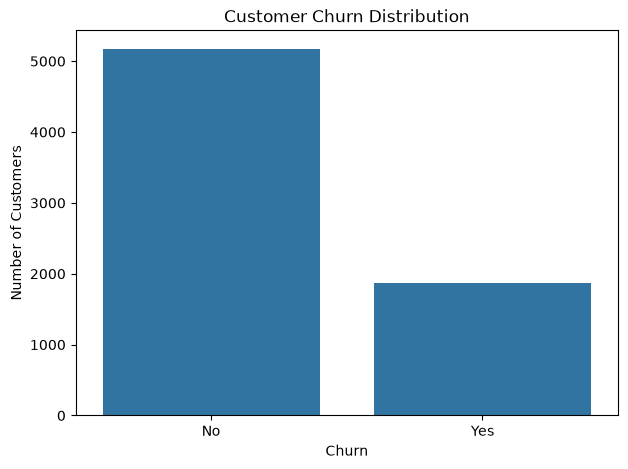

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [33]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


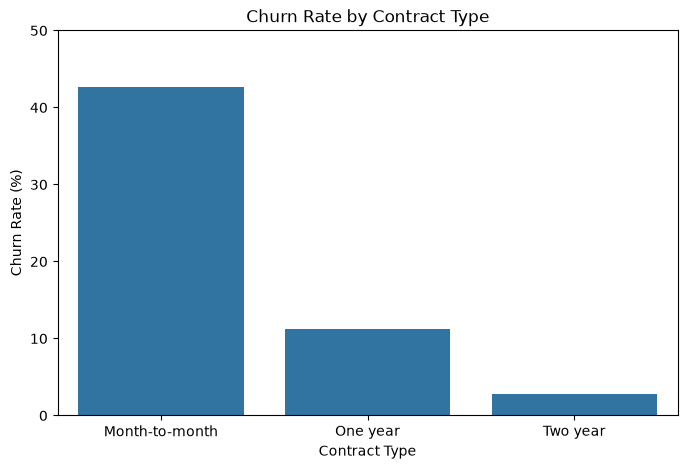

In [34]:
contract_churn_yes = contract_churn["Yes"]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn_yes.index,
    y=contract_churn_yes.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 50)

plt.show()

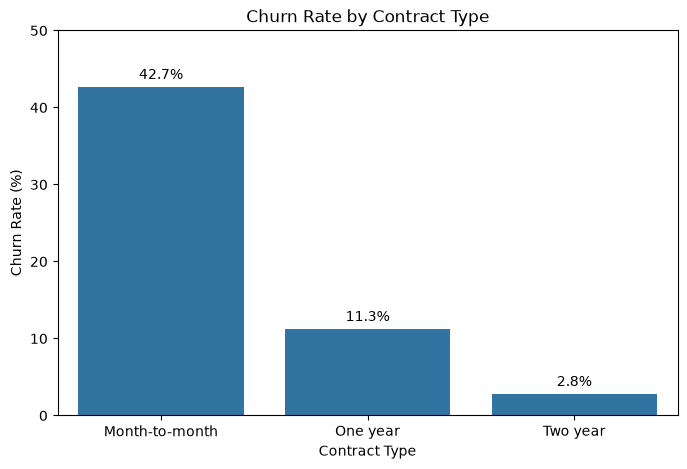

In [35]:
contract_churn_yes = contract_churn["Yes"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_churn_yes.index,
    y=contract_churn_yes.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for i, value in enumerate(contract_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

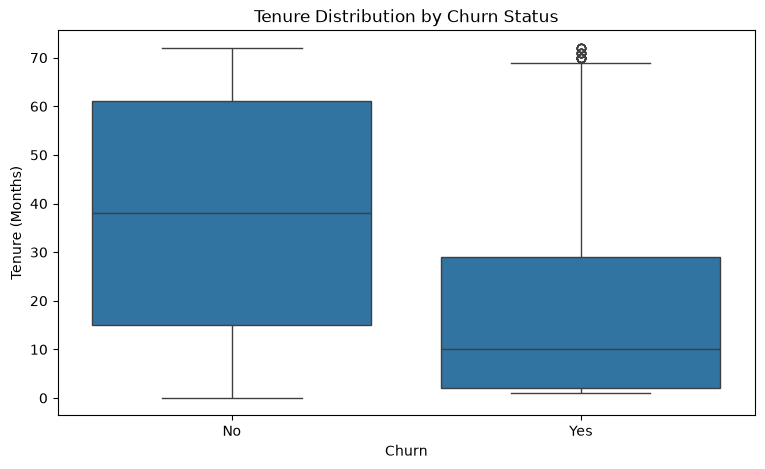

In [36]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [37]:
tenure_by_churn = df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
)

tenure_by_churn

,count,mean,median,min,max
Churn,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


In [38]:
monthly_charges_by_churn = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

monthly_charges_by_churn

,count,mean,median,min,max
Churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


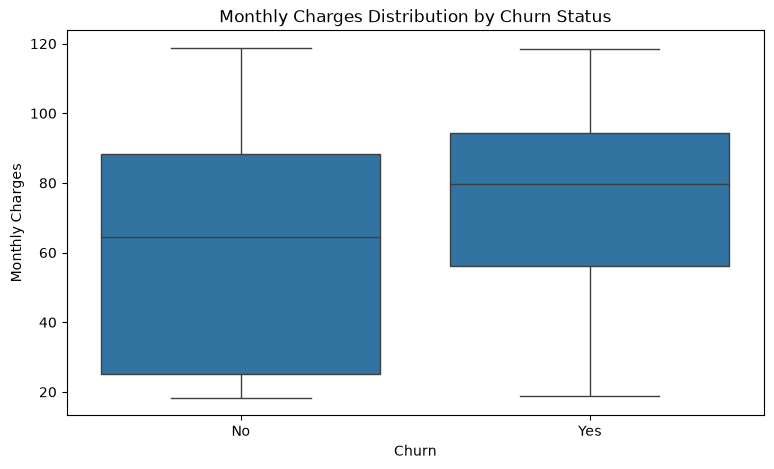

In [39]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [40]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


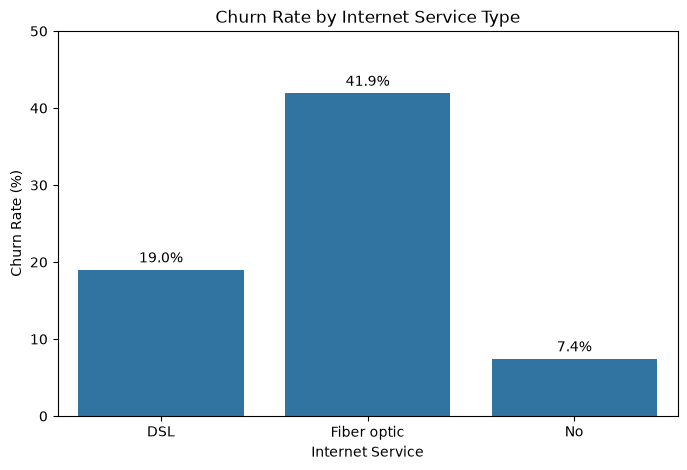

In [41]:
internet_churn_yes = internet_churn["Yes"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=internet_churn_yes.index,
    y=internet_churn_yes.values
)

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for i, value in enumerate(internet_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [42]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


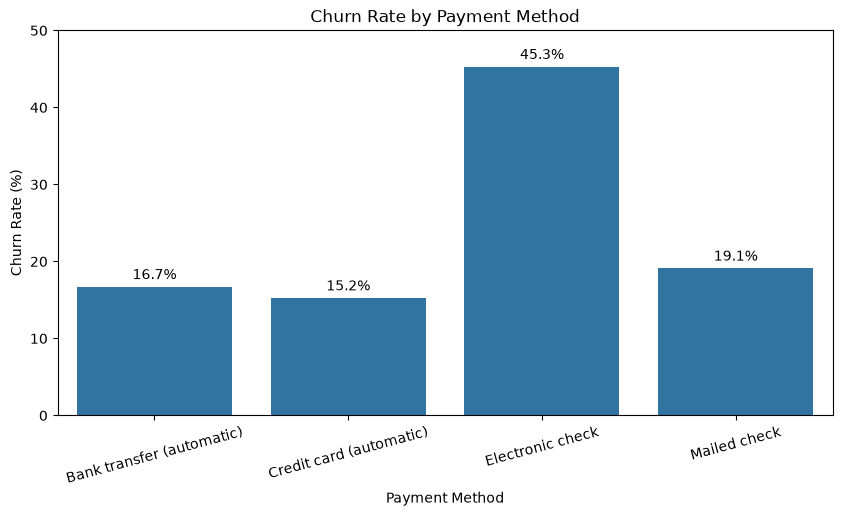

In [43]:
payment_churn_yes = payment_churn["Yes"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=payment_churn_yes.index,
    y=payment_churn_yes.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)
plt.xticks(rotation=15)

for i, value in enumerate(payment_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [44]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


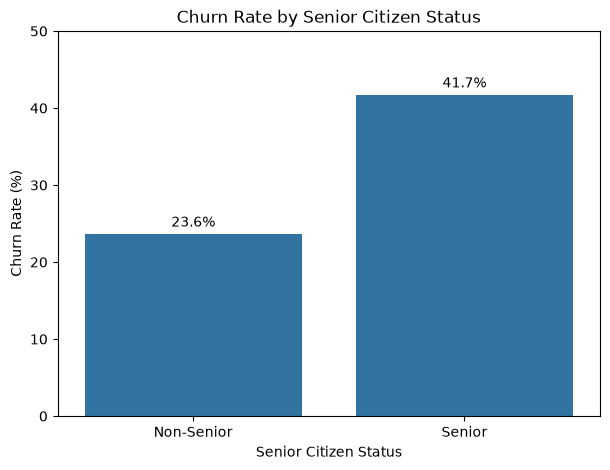

In [45]:
senior_churn_yes = senior_churn["Yes"]

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=senior_churn_yes.index.astype(str),
    y=senior_churn_yes.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen Status")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

plt.xticks(
    ticks=[0, 1],
    labels=["Non-Senior", "Senior"]
)

for i, value in enumerate(senior_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [46]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


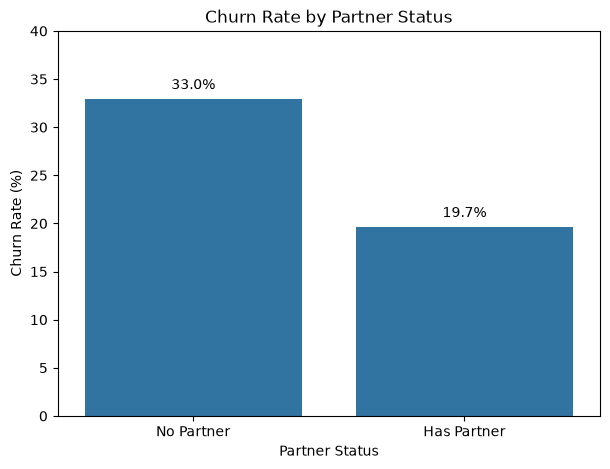

In [47]:
partner_churn_yes = partner_churn["Yes"]

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=partner_churn_yes.index,
    y=partner_churn_yes.values
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner Status")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 40)

plt.xticks(
    ticks=[0, 1],
    labels=["No Partner", "Has Partner"]
)

for i, value in enumerate(partner_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [48]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


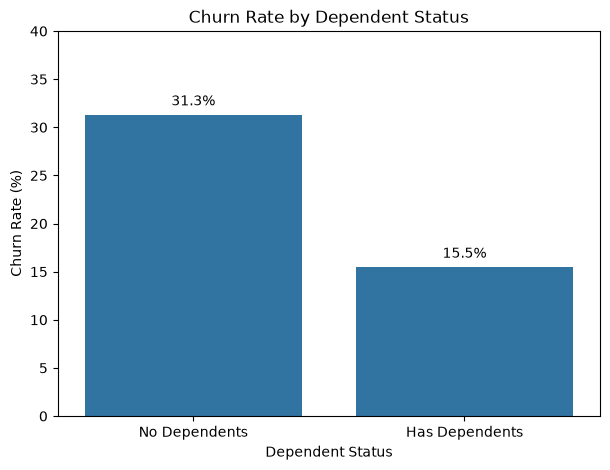

In [49]:
dependents_churn_yes = dependents_churn["Yes"]

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=dependents_churn_yes.index,
    y=dependents_churn_yes.values
)

plt.title("Churn Rate by Dependent Status")
plt.xlabel("Dependent Status")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 40)

plt.xticks(
    ticks=[0, 1],
    labels=["No Dependents", "Has Dependents"]
)

for i, value in enumerate(dependents_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [50]:
phone_churn = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

phone_churn

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [51]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


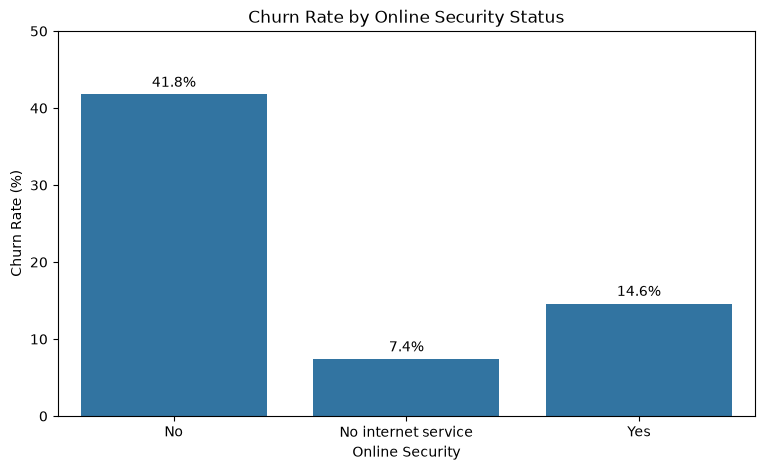

In [52]:
security_churn_yes = security_churn["Yes"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=security_churn_yes.index,
    y=security_churn_yes.values
)

plt.title("Churn Rate by Online Security Status")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for i, value in enumerate(security_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [53]:
backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

backup_churn

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


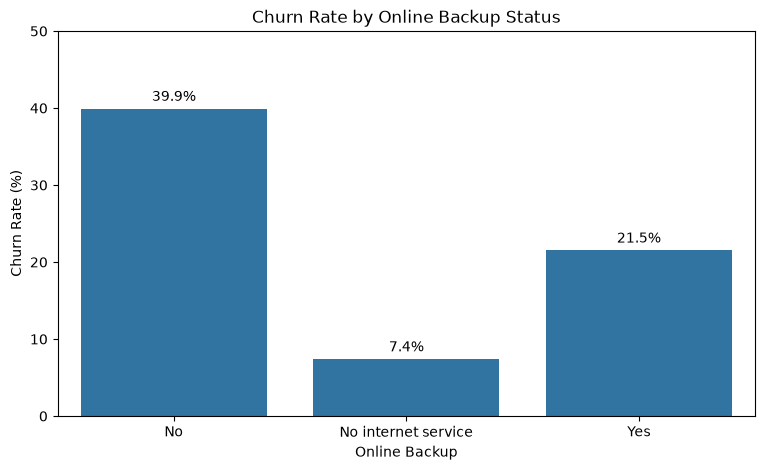

In [54]:
backup_churn_yes = backup_churn["Yes"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=backup_churn_yes.index,
    y=backup_churn_yes.values
)

plt.title("Churn Rate by Online Backup Status")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for i, value in enumerate(backup_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [55]:
device_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_churn

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


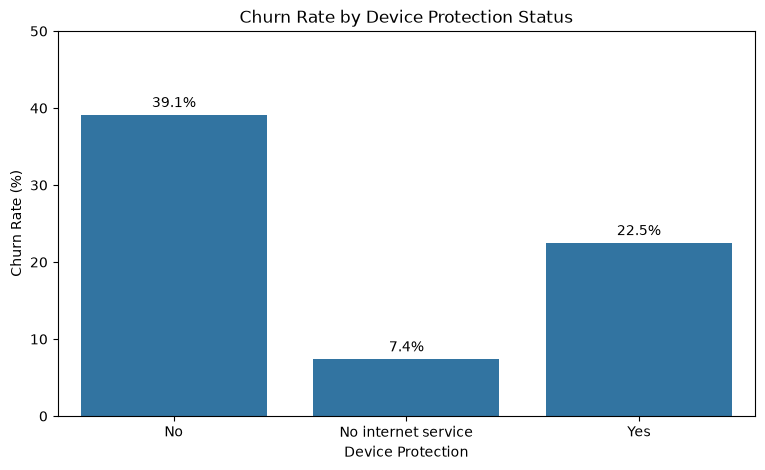

In [56]:
device_churn_yes = device_churn["Yes"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=device_churn_yes.index,
    y=device_churn_yes.values
)

plt.title("Churn Rate by Device Protection Status")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for i, value in enumerate(device_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [57]:
support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


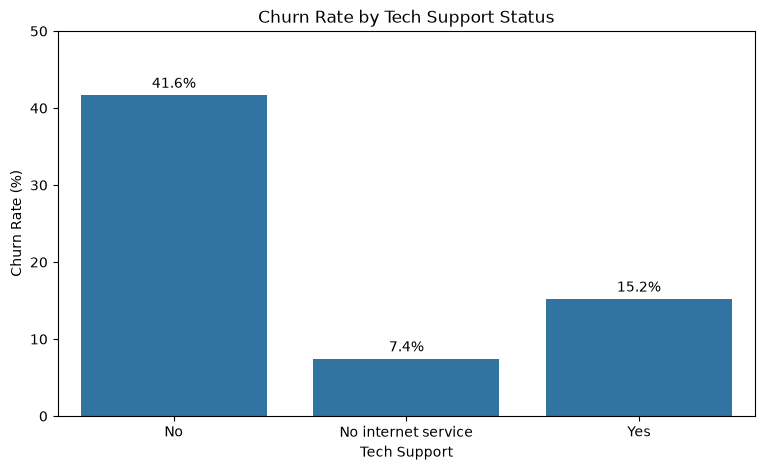

In [58]:
support_churn_yes = support_churn["Yes"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=support_churn_yes.index,
    y=support_churn_yes.values
)

plt.title("Churn Rate by Tech Support Status")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for i, value in enumerate(support_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [59]:
streaming_tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

streaming_tv_churn

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [60]:
streaming_movies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

streaming_movies_churn

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [61]:
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


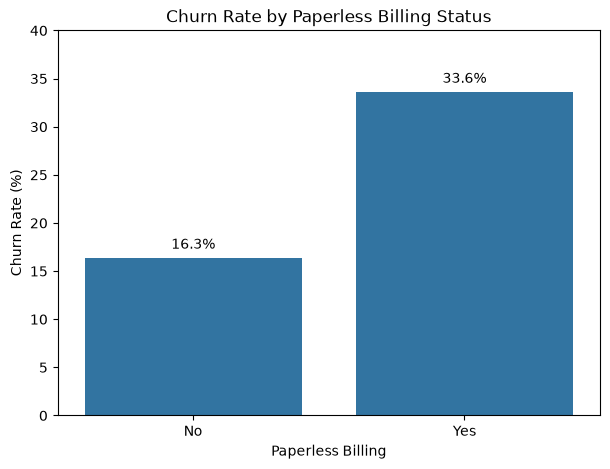

In [62]:
paperless_churn_yes = paperless_churn["Yes"]

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=paperless_churn_yes.index,
    y=paperless_churn_yes.values
)

plt.title("Churn Rate by Paperless Billing Status")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 40)

for i, value in enumerate(paperless_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()


In [63]:
multiple_lines_churn = pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
) * 100

multiple_lines_churn

Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


In [64]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [65]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [66]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [67]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [68]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


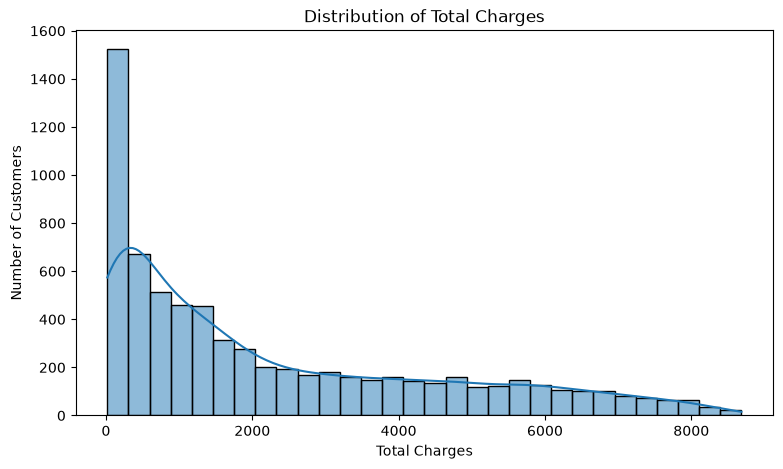

In [69]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

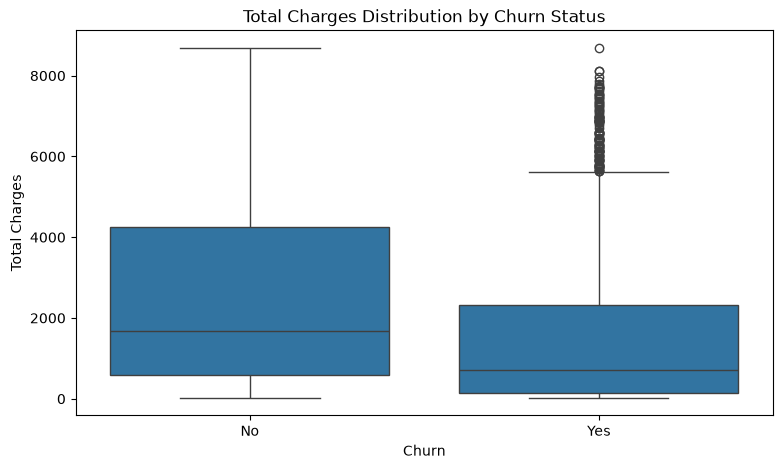

In [70]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [71]:
total_charges_by_churn = df.groupby("Churn")["TotalCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

total_charges_by_churn

,count,mean,median,min,max
Churn,,,,,
No,5163,2555.344141,1683.60,18.80,8672.45
Yes,1869,1531.796094,703.55,18.85,8684.80


In [72]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


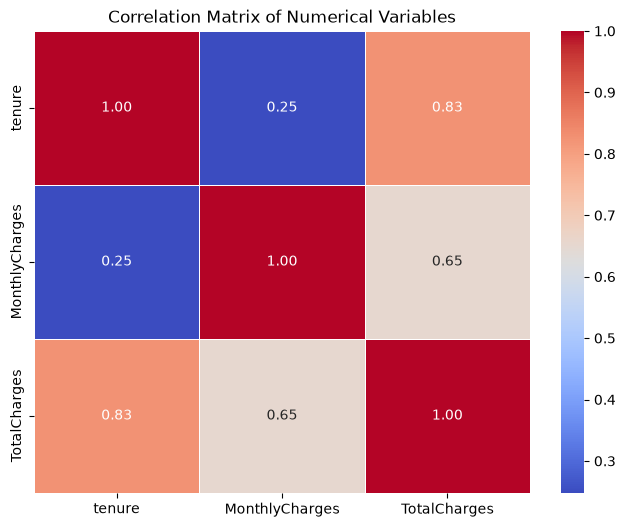

In [73]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [74]:
tenure_bins = [0, 12, 24, 48, 72]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [75]:
tenure_group_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_group_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


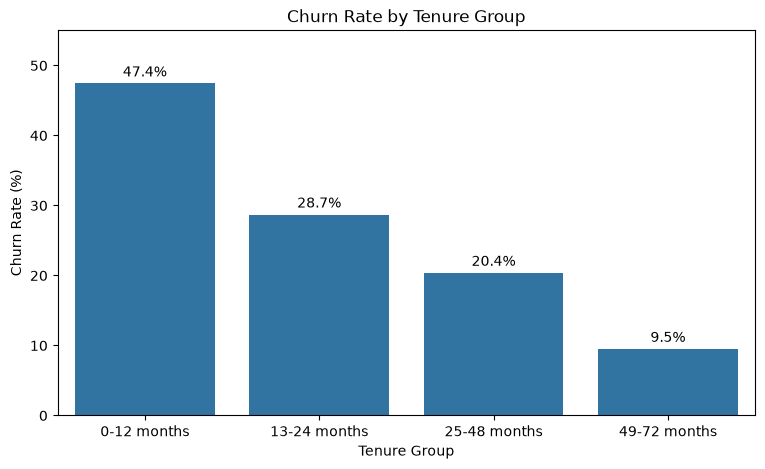

In [76]:
tenure_group_churn_yes = tenure_group_churn["Yes"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=tenure_group_churn_yes.index,
    y=tenure_group_churn_yes.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 55)

for i, value in enumerate(tenure_group_churn_yes.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [77]:
contract_tenure_churn = pd.crosstab(
    [df["TenureGroup"], df["Contract"]],
    df["Churn"],
    normalize="index"
) * 100

contract_tenure_churn

Churn                                No        Yes
TenureGroup  Contract                             
0-12 months  Month-to-month   48.645938  51.354062
             One year         89.516129  10.483871
             Two year        100.000000   0.000000
13-24 months Month-to-month   62.279512  37.720488
             One year         91.878173   8.121827
             Two year        100.000000   0.000000
25-48 months Month-to-month   67.082294  32.917706
             One year         89.382239  10.617761
             Two year         97.810219   2.189781
49-72 months Month-to-month   73.976608  26.023392
             One year         87.066246  12.933754
             Two year         96.674584   3.325416

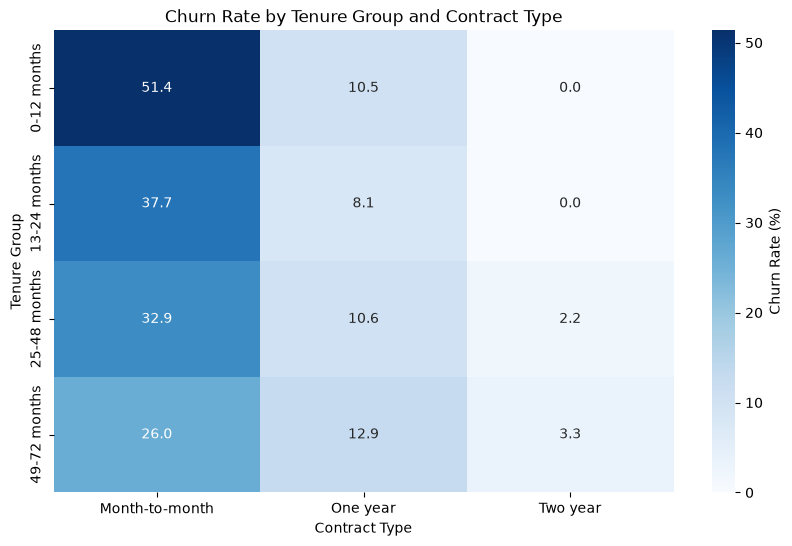

In [78]:
contract_tenure_yes = contract_tenure_churn["Yes"].unstack()

plt.figure(figsize=(10, 6))

sns.heatmap(
    contract_tenure_yes,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Churn Rate by Tenure Group and Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Tenure Group")

plt.show()

# EDA Summary

The exploratory analysis identified several notable patterns in the Telco Customer Churn dataset.

| Variable / Analysis | Key Observation | Interpretation |
|---|---|---|
| Churn Distribution | 26.54% of customers churned | The target variable is moderately imbalanced |
| Contract Type | Churn was 42.71% for month-to-month, 11.27% for one-year, and 2.83% for two-year contracts | Strong descriptive association with churn |
| Tenure | Mean tenure was 17.79 months for churned customers versus 37.57 months for non-churned customers | Churned customers generally had shorter tenure |
| Monthly Charges | Mean monthly charges were ₹74.44 for churned customers versus ₹61.26 for non-churned customers | Churned customers generally had higher monthly charges |
| Total Charges | Mean total charges were ₹1,531.80 for churned customers versus ₹2,555.34 for non-churned customers | Lower total charges were associated with churn, partly consistent with shorter tenure |
| Internet Service | Fiber optic customers had 41.89% observed churn compared with 18.96% for DSL and 7.40% for customers without internet service | Noticeable descriptive association |
| Payment Method | Electronic check customers had 45.29% observed churn, higher than the other payment methods | Noticeable descriptive association |
| Senior Citizen | Senior customers had 41.68% observed churn compared with 23.61% among non-senior customers | Noticeable descriptive association |
| Partner | Customers without a partner had 32.96% observed churn compared with 19.66% among customers with a partner | Noticeable descriptive association |
| Dependents | Customers without dependents had 31.28% observed churn compared with 15.45% among customers with dependents | Noticeable descriptive association |
| Online Security | Customers without online security had 41.77% observed churn compared with 14.61% among customers with online security | Noticeable descriptive association |
| Tech Support | Customers without tech support had 41.64% observed churn compared with 15.17% among customers with tech support | Noticeable descriptive association |
| Paperless Billing | Customers using paperless billing had 33.57% observed churn compared with 16.33% among those not using it | Noticeable descriptive association |
| Tenure × Contract | Month-to-month customers had higher observed churn within every tenure group | Combined descriptive association |
| Correlation | Tenure and Total Charges showed a correlation of 0.83 | Strong linear association between two numeric variables |

## Overall EDA Interpretation

The exploratory analysis indicates that churn is associated with several customer characteristics, particularly contract type, tenure, monthly charges, internet service, payment method, and selected additional services.

Shorter-tenure customers and customers on month-to-month contracts showed substantially higher observed churn rates. Several service-related and demographic variables also showed differences in churn rates between their categories.

These findings describe patterns within the available dataset and should not be interpreted as evidence of causation. The dataset represents a cross-sectional customer snapshot, so the analysis does not establish whether a particular characteristic directly causes customer churn.

The identified variables will be considered during the preprocessing and machine learning stages, where their predictive usefulness can be evaluated using appropriate models and evaluation metrics.

# Data Preprocessing

The preprocessing stage prepares the dataset for machine learning.

The main preprocessing tasks include:

1. Creating a separate modeling dataset
2. Handling missing values
3. Removing identifier and analysis-only columns
4. Separating features from the target
5. Encoding categorical variables
6. Splitting the dataset into training and testing sets
7. Preparing numerical and categorical features using appropriate transformations

The preprocessing workflow will be designed to avoid unnecessary data leakage and maintain reproducibility.

In [79]:
model_df = df.copy()

model_df.shape

(7043, 22)

In [80]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [81]:
model_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
TenureGroup          0
dtype: int64

In [82]:
model_df = model_df.drop(
    columns=["customerID", "TenureGroup"]
)

model_df.shape

(7043, 20)

In [83]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [84]:
model_df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [85]:
model_df[model_df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [86]:
model_df.loc[
    model_df["TotalCharges"].isnull(),
    "tenure"
].value_counts()

tenure
0    11
Name: count, dtype: int64

In [87]:
model_df["TotalCharges"] = model_df["TotalCharges"].fillna(0)

In [88]:
model_df["TotalCharges"].isnull().sum()

np.int64(0)

In [89]:
model_df.loc[
    model_df["tenure"] == 0,
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].head(15)

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,0.0,No
753,0,20.25,0.0,No
936,0,80.85,0.0,No
1082,0,25.75,0.0,No
1340,0,56.05,0.0,No
3331,0,19.85,0.0,No
3826,0,25.35,0.0,No
4380,0,20.00,0.0,No
5218,0,19.70,0.0,No
6670,0,73.35,0.0,No


## Missing Value Handling

The `TotalCharges` column initially contained 11 missing values out of 7,043 records.

Investigation showed that all 11 affected customers had a tenure of 0 months, while their monthly charges were available. These records were retained rather than removed because they represent valid observations in the dataset.

Since `TotalCharges` represents accumulated charges and these customers had zero recorded tenure, the missing `TotalCharges` values were replaced with 0.

After this treatment, the modeling dataset contains no missing values.

# Feature and Target Separation

The `Churn` column is the target variable that the machine learning models will predict.

All remaining customer attributes are treated as candidate input features.

The target variable is separated from the feature set before further preprocessing to maintain a clear distinction between predictors and the outcome.

In [90]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [91]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [92]:
y.value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [93]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [94]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [95]:
y.unique()

array([0, 1])

In [96]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX columns:")
print(X.columns.tolist())
print("\nTarget values:")
print(y.unique())

X shape: (7043, 19)
y shape: (7043,)

X columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target values:
[0 1]


In [97]:
from sklearn.model_selection import train_test_split

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [99]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)


In [100]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


## Train-Test Split

The dataset was divided into training and testing subsets using an 80:20 ratio.

The training set contains 5,634 observations, while the test set contains 1,409 observations.

A fixed random state of 42 was used to ensure reproducibility.

Stratified splitting was applied using the churn target so that the proportion of churned and non-churned customers remains approximately consistent between the training and testing sets.

The test set will remain unseen during model training and will be used for final model evaluation.

# Feature Preprocessing Pipeline

The dataset contains both numerical and categorical variables.

Numerical variables can be used directly by machine learning algorithms, although scaling may be beneficial for models such as Logistic Regression.

Categorical variables contain text-based categories and must be converted into numerical representations before they can be used by most machine learning algorithms.

A scikit-learn preprocessing pipeline will be used so that transformations are fitted on the training data and consistently applied to unseen test data.

In [101]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numeric_features) + len(categorical_features))

Numerical features: 4
Categorical features: 15
Total features: 19


In [102]:
print("Features not assigned to a preprocessing group:")
print(
    set(X.columns)
    - set(numeric_features)
    - set(categorical_features)
)

Features not assigned to a preprocessing group:
set()


In [103]:
print(
    "Features assigned to both groups:",
    set(numeric_features) & set(categorical_features)
)

Features assigned to both groups: set()


In [104]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [105]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [106]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [108]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [109]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5634, 19)
Processed training shape: (5634, 45)

Original testing shape: (1409, 19)
Processed testing shape: (1409, 45)


In [110]:
import numpy as np

print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [111]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of processed features: 45

Feature names:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 

In [112]:
print("Processed training shape:", X_train_processed.shape)
print("Number of feature names:", len(feature_names))

Processed training shape: (5634, 45)
Number of feature names: 45


In [113]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
3738,-0.441773,0.102371,-0.521976,-0.262257,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3151,-0.441773,-0.711743,0.337478,-0.503635,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4860,-0.441773,-0.793155,-0.809013,-0.749883,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3867,-0.441773,-0.263980,0.284384,-0.172722,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3810,-0.441773,-1.281624,-0.676279,-0.989374,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [114]:
X_train_processed_df.dtypes.value_counts()

float64    45
Name: count, dtype: int64

In [115]:
X_train_processed_df.shape

(5634, 45)

In [116]:
from sklearn.linear_model import LogisticRegression

In [117]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [118]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [119]:
print("Number of iterations:", logistic_model.n_iter_)

Number of iterations: [42]


In [120]:
y_pred = logistic_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [121]:
y_pred_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

print("First 20 churn probabilities:")
print(y_pred_proba[:20])

First 20 churn probabilities:
[0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874 0.26917442 0.06229858
 0.129104   0.68577555 0.12916234 0.05778687 0.03232227 0.63681471
 0.1804334  0.08490458]


In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [123]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-score : 0.6040
ROC-AUC  : 0.8421


In [124]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [125]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


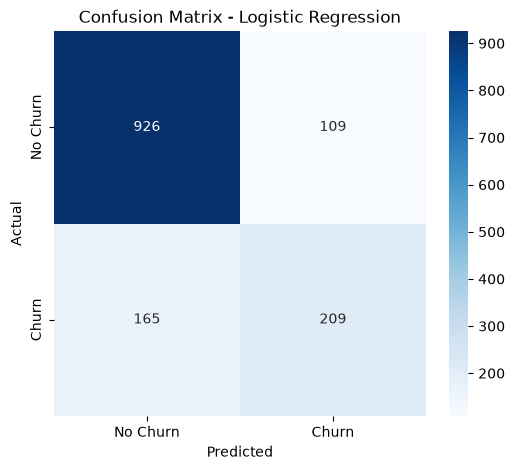

In [126]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [127]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8055358410220014,
 'Precision': 0.6572327044025157,
 'Recall': 0.5588235294117647,
 'F1-Score': 0.6040462427745664,
 'ROC-AUC': 0.8421349040274871}

In [128]:
coefficients = logistic_model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df.head(10)

,Feature,Coefficient
0,num__SeniorCitizen,0.053449
1,num__tenure,-1.257539
2,num__MonthlyCharges,-0.591863
3,num__TotalCharges,0.536253
4,cat__gender_Female,-0.168134
5,cat__gender_Male,-0.146421
6,cat__Partner_No,-0.167425
7,cat__Partner_Yes,-0.147130
8,cat__Dependents_No,-0.046067
9,cat__Dependents_Yes,-0.268487


In [129]:
coefficient_df_sorted = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df_sorted.head(15)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.634195
36,cat__Contract_Month-to-month,0.582883
3,num__TotalCharges,0.536253
35,cat__StreamingMovies_Yes,0.200938
32,cat__StreamingTV_Yes,0.200481
43,cat__PaymentMethod_Electronic check,0.197867
18,cat__OnlineSecurity_No,0.156279
27,cat__TechSupport_No,0.131503
14,cat__MultipleLines_Yes,0.104649
0,num__SeniorCitizen,0.053449


In [130]:
coefficient_df_sorted.tail(15)

,Feature,Coefficient
33,cat__StreamingMovies_No,-0.215388
9,cat__Dependents_Yes,-0.268487
12,cat__MultipleLines_No,-0.279394
34,cat__StreamingMovies_No internet service,-0.300104
28,cat__TechSupport_No internet service,-0.300104
19,cat__OnlineSecurity_No internet service,-0.300104
17,cat__InternetService_No,-0.300104
31,cat__StreamingTV_No internet service,-0.300104
25,cat__DeviceProtection_No internet service,-0.300104
22,cat__OnlineBackup_No internet service,-0.300104


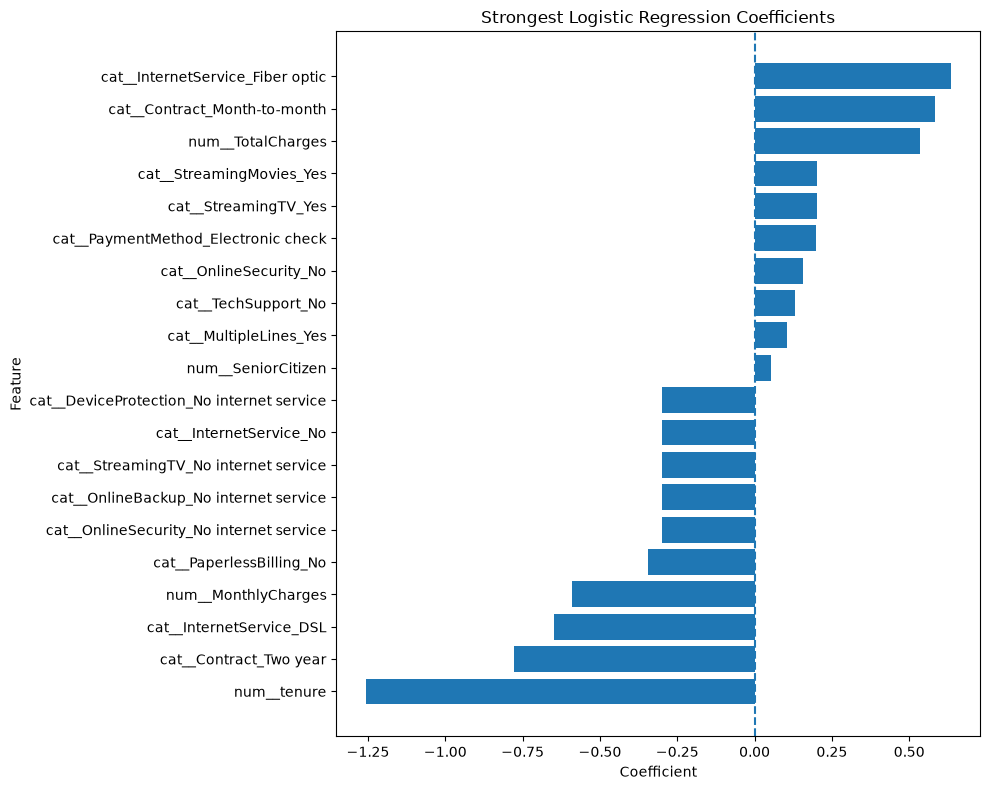

In [131]:
top_positive = coefficient_df_sorted.head(10)
top_negative = coefficient_df_sorted.tail(10)

top_coefficients = pd.concat([
    top_positive,
    top_negative
]).sort_values(by="Coefficient")

plt.figure(figsize=(10, 8))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Strongest Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [132]:
coefficient_df.to_csv(
    "../reports/logistic_regression_coefficients.csv",
    index=False
)

In [133]:
from sklearn.tree import DecisionTreeClassifier

In [134]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [135]:
decision_tree.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [136]:
dt_pred = decision_tree.predict(X_test_processed)

print("First 20 predictions:")
print(dt_pred[:20])

First 20 predictions:
[0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0]


In [137]:
dt_pred_proba = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

print("First 20 churn probabilities:")
print(dt_pred_proba[:20])

First 20 churn probabilities:
[0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0.]


In [138]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_pred_proba)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")

Accuracy : 0.7211
Precision: 0.4755
Recall   : 0.4920
F1-score : 0.4836
ROC-AUC  : 0.6477


In [139]:
print(classification_report(
    y_test,
    dt_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.81      0.80      0.81      1035
       Churn       0.48      0.49      0.48       374

    accuracy                           0.72      1409
   macro avg       0.64      0.65      0.65      1409
weighted avg       0.72      0.72      0.72      1409



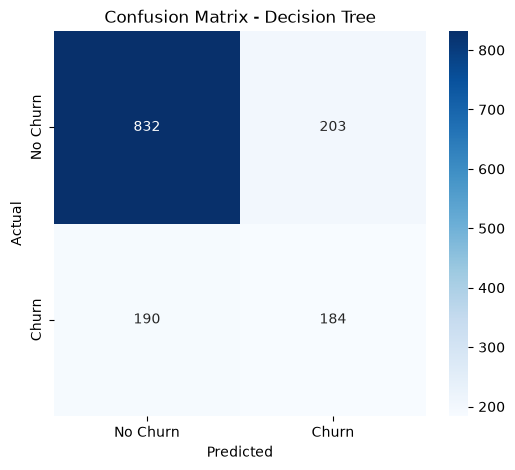

In [140]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [141]:
decision_tree_results = {
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1-Score": dt_f1,
    "ROC-AUC": dt_roc_auc
}

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.7210787792760823,
 'Precision': 0.4754521963824289,
 'Recall': 0.4919786096256685,
 'F1-Score': 0.4835742444152431,
 'ROC-AUC': 0.6476762510010592}

In [142]:
model_results = pd.DataFrame([
    logistic_results,
    decision_tree_results
])

model_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Decision Tree,0.721079,0.475452,0.491979,0.483574,0.647676


In [143]:
model_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477


In [144]:
model_results[
    ["Model", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6572,0.5588,0.6040,0.8421
1,Decision Tree,0.4755,0.4920,0.4836,0.6477


In [145]:
model_results.to_csv(
    "../reports/baseline_model_comparison.csv",
    index=False
)

# Baseline Model Comparison

Two baseline classification models were evaluated:

1. Logistic Regression
2. Decision Tree

Both models were trained using the same training and testing datasets and the same preprocessing workflow.

The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Because the target variable is imbalanced, performance was not assessed using accuracy alone. Precision, recall, F1-score, and ROC-AUC provide additional information about the models' ability to distinguish churned customers from non-churned customers.

The baseline results will be used as a reference point for evaluating additional models and subsequent model improvements.

In [146]:
from sklearn.ensemble import RandomForestClassifier

In [147]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [148]:
random_forest.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [149]:
rf_pred = random_forest.predict(
    X_test_processed
)

print("First 20 predictions:")
print(rf_pred[:20])

First 20 predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [150]:
rf_pred_proba = random_forest.predict_proba(
    X_test_processed
)[:, 1]

print("First 20 churn probabilities:")
print(rf_pred_proba[:20])

First 20 churn probabilities:
[0.    0.725 0.07  0.305 0.015 0.33  0.37  0.045 0.01  0.445 0.18  0.
 0.26  0.74  0.085 0.09  0.05  0.56  0.18  0.095]


In [151]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Accuracy : 0.7835
Precision: 0.6186
Recall   : 0.4813
F1-score : 0.5414
ROC-AUC  : 0.8206


In [152]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



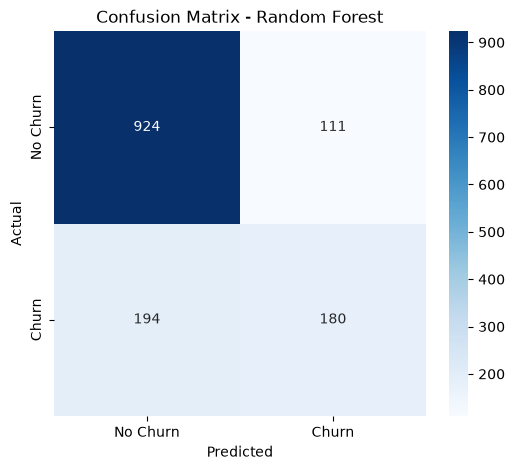

In [153]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [154]:
random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "ROC-AUC": rf_roc_auc
}

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.7835344215755855,
 'Precision': 0.6185567010309279,
 'Recall': 0.48128342245989303,
 'F1-Score': 0.5413533834586466,
 'ROC-AUC': 0.820602443876101}

In [155]:
model_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results
])

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
2,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206


In [156]:
model_results.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
2,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477


In [157]:
model_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
2,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206


In [158]:
model_results.to_csv(
    "../reports/baseline_model_comparison.csv",
    index=False
)

### Baseline Model Comparison

Three classification algorithms have now been evaluated using the same training and testing datasets:

- Logistic Regression
- Decision Tree
- Random Forest

The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

The results provide baseline performance measurements before hyperparameter tuning or additional model optimization. No overall model selection is made at this stage.

In [159]:
from xgboost import XGBClassifier

In [160]:
xgboost_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [161]:
xgboost_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [162]:
xgb_pred = xgboost_model.predict(
    X_test_processed
)

print("First 20 predictions:")
print(xgb_pred[:20])

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [163]:
xgb_pred_proba = xgboost_model.predict_proba(
    X_test_processed
)[:, 1]

print("First 20 churn probabilities:")
print(xgb_pred_proba[:20])

First 20 churn probabilities:
[0.00866993 0.86659    0.06799064 0.44690815 0.00255073 0.5639479
 0.49796873 0.08933154 0.01711917 0.48394144 0.34571153 0.00624487
 0.29015955 0.77170205 0.10838895 0.03470878 0.0126754  0.71389943
 0.23029515 0.05651942]


In [164]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

Accuracy : 0.8013
Precision: 0.6567
Recall   : 0.5267
F1-score : 0.5846
ROC-AUC  : 0.8384


In [165]:
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



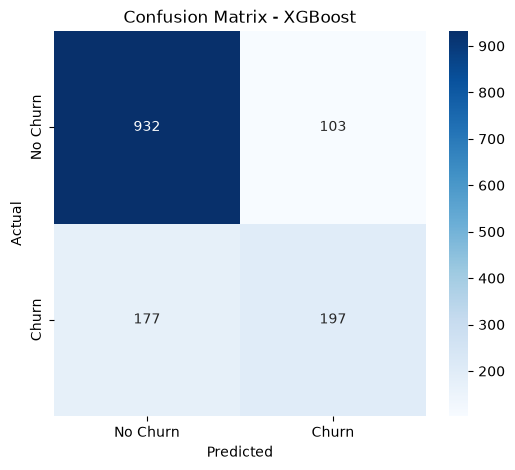

In [166]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [167]:
xgboost_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-Score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
}

xgboost_results

{'Model': 'XGBoost',
 'Accuracy': 0.801277501774308,
 'Precision': 0.6566666666666666,
 'Recall': 0.5267379679144385,
 'F1-Score': 0.5845697329376854,
 'ROC-AUC': 0.8384122555478054}

In [168]:
model_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    xgboost_results
])

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
2,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206
3,XGBoost,0.8013,0.6567,0.5267,0.5846,0.8384


In [169]:
baseline_comparison = model_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].round(4)

baseline_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
2,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206
3,XGBoost,0.8013,0.6567,0.5267,0.5846,0.8384


In [170]:
baseline_comparison.to_csv(
    "../reports/baseline_model_comparison.csv",
    index=False
)

<Figure size 1000x600 with 0 Axes>

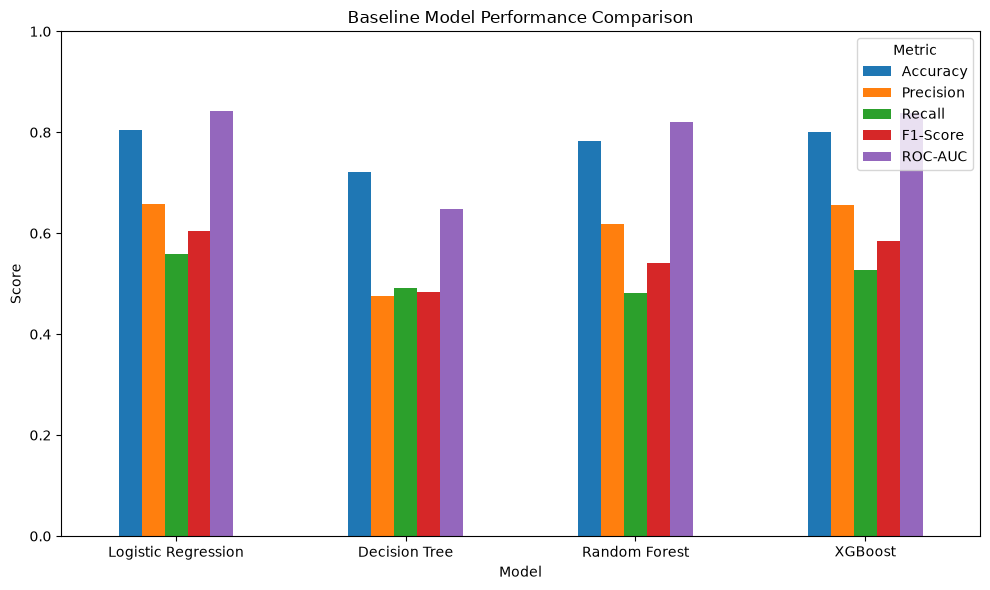

In [171]:
plt.figure(figsize=(10, 6))

baseline_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

# Baseline Model Evaluation

Four classification algorithms were evaluated as baseline models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

All models used the same training and testing partitions and the same preprocessing workflow.

The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

The baseline comparison provides an initial assessment of how different algorithm families perform on the churn prediction task. These results are not treated as final model-selection evidence because the test set should remain reserved for final evaluation.

The next stage will use cross-validation on the training data to obtain more robust estimates during model comparison and hyperparameter tuning.

In [172]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [173]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [174]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [175]:
logistic_cv = cross_validate(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [176]:
for metric in scoring:
    scores = logistic_cv[f"test_{metric}"]
    print(
        f"{metric.upper():<10} "
        f"Mean: {scores.mean():.4f} "
        f"Std: {scores.std():.4f}"
    )

ACCURACY   Mean: 0.8019 Std: 0.0120
PRECISION  Mean: 0.6520 Std: 0.0257
RECALL     Mean: 0.5438 Std: 0.0424
F1         Mean: 0.5924 Std: 0.0307
ROC_AUC    Mean: 0.8462 Std: 0.0126


In [177]:
def evaluate_with_cv(model, X_data, y_data, cv, scoring):
    results = cross_validate(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    summary = {}

    for metric in scoring:
        scores = results[f"test_{metric}"]
        summary[f"{metric}_mean"] = scores.mean()
        summary[f"{metric}_std"] = scores.std()

    return summary

In [178]:
logistic_cv_summary = evaluate_with_cv(
    logistic_model,
    X_train_processed,
    y_train,
    cv,
    scoring
)

logistic_cv_summary

{'accuracy_mean': np.float64(0.8019183578906889),
 'accuracy_std': np.float64(0.01197924291891647),
 'precision_mean': np.float64(0.6520490368155147),
 'precision_std': np.float64(0.025654212940614127),
 'recall_mean': np.float64(0.5438127090301004),
 'recall_std': np.float64(0.0423892428568692),
 'f1_mean': np.float64(0.5923569127009536),
 'f1_std': np.float64(0.030659844351499606),
 'roc_auc_mean': np.float64(0.8461918676556731),
 'roc_auc_std': np.float64(0.012560360752677987)}

In [179]:
decision_tree_cv_summary = evaluate_with_cv(
    decision_tree,
    X_train_processed,
    y_train,
    cv,
    scoring
)

decision_tree_cv_summary

{'accuracy_mean': np.float64(0.7261268303753659),
 'accuracy_std': np.float64(0.006249488999448716),
 'precision_mean': np.float64(0.48456557821189233),
 'precision_std': np.float64(0.011722918332017704),
 'recall_mean': np.float64(0.4983277591973244),
 'recall_std': np.float64(0.025027808607183538),
 'f1_mean': np.float64(0.49102868455726717),
 'f1_std': np.float64(0.01416675823404318),
 'roc_auc_mean': np.float64(0.6534787862135439),
 'roc_auc_std': np.float64(0.00990786969689401)}

In [180]:
random_forest_cv_summary = evaluate_with_cv(
    random_forest,
    X_train_processed,
    y_train,
    cv,
    scoring
)

random_forest_cv_summary

{'accuracy_mean': np.float64(0.7832819806430564),
 'accuracy_std': np.float64(0.013408721108523093),
 'precision_mean': np.float64(0.6205421855426072),
 'precision_std': np.float64(0.03337012727497982),
 'recall_mean': np.float64(0.4729096989966555),
 'recall_std': np.float64(0.03184115113153686),
 'f1_mean': np.float64(0.5364071012555555),
 'f1_std': np.float64(0.029927885443639606),
 'roc_auc_mean': np.float64(0.8197763264491),
 'roc_auc_std': np.float64(0.012685328605421856)}

In [181]:
xgboost_cv_summary = evaluate_with_cv(
    xgboost_model,
    X_train_processed,
    y_train,
    cv,
    scoring
)

xgboost_cv_summary

{'accuracy_mean': np.float64(0.7999675335421064),
 'accuracy_std': np.float64(0.013701010347206666),
 'precision_mean': np.float64(0.6560734558642232),
 'precision_std': np.float64(0.037956909494794),
 'recall_mean': np.float64(0.5204013377926422),
 'recall_std': np.float64(0.02688929932072477),
 'f1_mean': np.float64(0.5799715530543895),
 'f1_std': np.float64(0.026729258514535507),
 'roc_auc_mean': np.float64(0.841396270811871),
 'roc_auc_std': np.float64(0.009886890842302428)}

In [182]:
cv_results = pd.DataFrame([
    {"Model": "Logistic Regression", **logistic_cv_summary},
    {"Model": "Decision Tree", **decision_tree_cv_summary},
    {"Model": "Random Forest", **random_forest_cv_summary},
    {"Model": "XGBoost", **xgboost_cv_summary}
])

cv_results.round(4)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.8019,0.0120,0.6520,0.0257,0.5438,0.0424,0.5924,0.0307,0.8462,0.0126
1,Decision Tree,0.7261,0.0062,0.4846,0.0117,0.4983,0.0250,0.4910,0.0142,0.6535,0.0099
2,Random Forest,0.7833,0.0134,0.6205,0.0334,0.4729,0.0318,0.5364,0.0299,0.8198,0.0127
3,XGBoost,0.8000,0.0137,0.6561,0.0380,0.5204,0.0269,0.5800,0.0267,0.8414,0.0099


In [183]:
cv_comparison = cv_results[
    [
        "Model",
        "accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "roc_auc_mean"
    ]
].round(4)

cv_comparison

,Model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Logistic Regression,0.8019,0.6520,0.5438,0.5924,0.8462
1,Decision Tree,0.7261,0.4846,0.4983,0.4910,0.6535
2,Random Forest,0.7833,0.6205,0.4729,0.5364,0.8198
3,XGBoost,0.8000,0.6561,0.5204,0.5800,0.8414


In [184]:
cv_comparison.to_csv(
    "../reports/cross_validation_comparison.csv",
    index=False
)

In [185]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [186]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [187]:
pipeline_pred = logistic_pipeline.predict(X_test)

pipeline_pred_proba = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Predictions:", pipeline_pred[:20])
print("Probabilities:", pipeline_pred_proba[:10])

Predictions: [0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
Probabilities: [0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874]


In [188]:
pipeline_roc_auc = roc_auc_score(
    y_test,
    pipeline_pred_proba
)

pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_pred
)

print(f"Pipeline Accuracy: {pipeline_accuracy:.4f}")
print(f"Pipeline ROC-AUC: {pipeline_roc_auc:.4f}")

Pipeline Accuracy: 0.8055
Pipeline ROC-AUC: 0.8421


In [189]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]
)

In [190]:
logistic_pipeline_cv = evaluate_with_cv(
    logistic_pipeline,
    X_train,
    y_train,
    cv,
    scoring
)

logistic_pipeline_cv

{'accuracy_mean': np.float64(0.802095977784117),
 'accuracy_std': np.float64(0.011839842689786047),
 'precision_mean': np.float64(0.6529272596206235),
 'precision_std': np.float64(0.02617550991267593),
 'recall_mean': np.float64(0.5431438127090301),
 'recall_std': np.float64(0.04110312105882869),
 'f1_mean': np.float64(0.5923285102625757),
 'f1_std': np.float64(0.029850897224643135),
 'roc_auc_mean': np.float64(0.8462007441910661),
 'roc_auc_std': np.float64(0.012576130140361557)}

In [191]:
decision_tree_pipeline_cv = evaluate_with_cv(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv,
    scoring
)

decision_tree_pipeline_cv

{'accuracy_mean': np.float64(0.7266595324514855),
 'accuracy_std': np.float64(0.007424414962056274),
 'precision_mean': np.float64(0.48545896012331324),
 'precision_std': np.float64(0.013938749634125724),
 'recall_mean': np.float64(0.4969899665551839),
 'recall_std': np.float64(0.02284063020597172),
 'f1_mean': np.float64(0.49092011357102383),
 'f1_std': np.float64(0.015060099230077938),
 'roc_auc_mean': np.float64(0.6533542670893723),
 'roc_auc_std': np.float64(0.01060638764653182)}

In [192]:
random_forest_pipeline_cv = evaluate_with_cv(
    random_forest_pipeline,
    X_train,
    y_train,
    cv,
    scoring
)

random_forest_pipeline_cv

{'accuracy_mean': np.float64(0.7838146827191762),
 'accuracy_std': np.float64(0.012770365796409609),
 'precision_mean': np.float64(0.622175273711524),
 'precision_std': np.float64(0.03297782004182343),
 'recall_mean': np.float64(0.4735785953177258),
 'recall_std': np.float64(0.029583069414710336),
 'f1_mean': np.float64(0.537423524757803),
 'f1_std': np.float64(0.027751274988987842),
 'roc_auc_mean': np.float64(0.8198789726842817),
 'roc_auc_std': np.float64(0.012600126185655208)}

In [193]:
xgboost_pipeline_cv = evaluate_with_cv(
    xgboost_pipeline,
    X_train,
    y_train,
    cv,
    scoring
)

xgboost_pipeline_cv

{'accuracy_mean': np.float64(0.7999675335421064),
 'accuracy_std': np.float64(0.013701010347206666),
 'precision_mean': np.float64(0.6560734558642232),
 'precision_std': np.float64(0.037956909494794),
 'recall_mean': np.float64(0.5204013377926422),
 'recall_std': np.float64(0.02688929932072477),
 'f1_mean': np.float64(0.5799715530543895),
 'f1_std': np.float64(0.026729258514535507),
 'roc_auc_mean': np.float64(0.841396270811871),
 'roc_auc_std': np.float64(0.009886890842302428)}

In [194]:
pipeline_cv_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_pipeline_cv
    },
    {
        "Model": "Decision Tree",
        **decision_tree_pipeline_cv
    },
    {
        "Model": "Random Forest",
        **random_forest_pipeline_cv
    },
    {
        "Model": "XGBoost",
        **xgboost_pipeline_cv
    }
])

pipeline_cv_comparison = pipeline_cv_results[
    [
        "Model",
        "accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "roc_auc_mean"
    ]
].round(4)

pipeline_cv_comparison

,Model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Logistic Regression,0.8021,0.6529,0.5431,0.5923,0.8462
1,Decision Tree,0.7267,0.4855,0.4970,0.4909,0.6534
2,Random Forest,0.7838,0.6222,0.4736,0.5374,0.8199
3,XGBoost,0.8000,0.6561,0.5204,0.5800,0.8414


In [195]:
pipeline_cv_comparison.to_csv(
    "../reports/pipeline_cross_validation_comparison.csv",
    index=False
)

In [196]:
from sklearn.model_selection import GridSearchCV

## Hyperparameter Tuning

Hyperparameter tuning is used to identify model configurations that provide strong cross-validated performance without relying on the held-out test set.

GridSearchCV will be used to evaluate predefined combinations of hyperparameters using stratified cross-validation on the training data.

ROC-AUC is selected as the primary optimization metric because the task is binary classification and the target variable is imbalanced.

Other metrics including precision, recall, F1-score, and accuracy will also be reported during final model evaluation.

In [197]:
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

In [198]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [199]:
logistic_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [200]:
print("Best parameters:")
print(logistic_grid.best_params_)

print("\nBest cross-validated ROC-AUC:")
print(f"{logistic_grid.best_score_:.4f}")

Best parameters:
{'classifier__C': 10, 'classifier__solver': 'liblinear'}

Best cross-validated ROC-AUC:
0.8464


In [201]:
decision_tree_param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5]
}

In [202]:
decision_tree_grid = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [203]:
decision_tree_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Su

In [204]:
print("Best parameters:")
print(decision_tree_grid.best_params_)

print("\nBest cross-validated ROC-AUC:")
print(f"{decision_tree_grid.best_score_:.4f}")

Best parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}

Best cross-validated ROC-AUC:
0.8291


In [205]:
random_forest_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [206]:
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [207]:
random_forest_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated 

In [208]:
print("Best parameters:")
print(random_forest_grid.best_params_)

print("\nBest cross-validated ROC-AUC:")
print(f"{random_forest_grid.best_score_:.4f}")

Best parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best cross-validated ROC-AUC:
0.8459


In [209]:
xgboost_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [3, 4, 5],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

In [210]:
xgboost_grid = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=xgboost_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [211]:
xgboost_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-v

In [212]:
print("Best parameters:")
print(xgboost_grid.best_params_)

print("\nBest cross-validated ROC-AUC:")
print(f"{xgboost_grid.best_score_:.4f}")

Best parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

Best cross-validated ROC-AUC:
0.8504


In [213]:
xgboost_grid.best_params_

{'classifier__colsample_bytree': 0.8,
 'classifier__learning_rate': 0.05,
 'classifier__max_depth': 3,
 'classifier__n_estimators': 100,
 'classifier__subsample': 0.8}

In [214]:
tuned_model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best CV ROC-AUC": logistic_grid.best_score_
    },
    {
        "Model": "Decision Tree",
        "Best CV ROC-AUC": decision_tree_grid.best_score_
    },
    {
        "Model": "Random Forest",
        "Best CV ROC-AUC": random_forest_grid.best_score_
    },
    {
        "Model": "XGBoost",
        "Best CV ROC-AUC": xgboost_grid.best_score_
    }
])

tuned_model_results.round(4)

,Model,Best CV ROC-AUC
0,Logistic Regression,0.8464
1,Decision Tree,0.8291
2,Random Forest,0.8459
3,XGBoost,0.8504


In [215]:
import pandas as pdimport pandas as pd

SyntaxError: invalid syntax (743457635.py, line 1)

In [ ]:
import pandas as pd

In [ ]:
tuned_model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best CV ROC-AUC": logistic_grid.best_score_
    },
    {
        "Model": "Decision Tree",
        "Best CV ROC-AUC": decision_tree_grid.best_score_
    },
    {
        "Model": "Random Forest",
        "Best CV ROC-AUC": random_forest_grid.best_score_
    },
    {
        "Model": "XGBoost",
        "Best CV ROC-AUC": xgboost_grid.best_score_
    }
])

tuned_model_results.round(4)

NameError: name 'logistic_grid' is not defined

In [ ]:
print("X_train exists:", "X_train" in globals())
print("y_train exists:", "y_train" in globals())
print("X_test exists:", "X_test" in globals())
print("y_test exists:", "y_test" in globals())
print("preprocessor exists:", "preprocessor" in globals())

X_train exists: False
y_train exists: False
X_test exists: False
y_test exists: False
preprocessor exists: False


In [216]:
print("X_train exists:", "X_train" in globals())
print("y_train exists:", "y_train" in globals())
print("X_test exists:", "X_test" in globals())
print("y_test exists:", "y_test" in globals())
print("preprocessor exists:", "preprocessor" in globals())
print("logistic_grid exists:", "logistic_grid" in globals())
print("decision_tree_grid exists:", "decision_tree_grid" in globals())
print("random_forest_grid exists:", "random_forest_grid" in globals())
print("xgboost_grid exists:", "xgboost_grid" in globals())

X_train exists: True
y_train exists: True
X_test exists: True
y_test exists: True
preprocessor exists: True
logistic_grid exists: True
decision_tree_grid exists: True
random_forest_grid exists: True
xgboost_grid exists: True


In [217]:
print("Logistic:", logistic_grid.best_score_)
print("Decision Tree:", decision_tree_grid.best_score_)
print("Random Forest:", random_forest_grid.best_score_)
print("XGBoost:", xgboost_grid.best_score_)

Logistic: 0.8463979435508616
Decision Tree: 0.8290997129050837
Random Forest: 0.8459424025287156
XGBoost: 0.8504440148111445


In [218]:
tuned_model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best CV ROC-AUC": logistic_grid.best_score_
    },
    {
        "Model": "Decision Tree",
        "Best CV ROC-AUC": decision_tree_grid.best_score_
    },
    {
        "Model": "Random Forest",
        "Best CV ROC-AUC": random_forest_grid.best_score_
    },
    {
        "Model": "XGBoost",
        "Best CV ROC-AUC": xgboost_grid.best_score_
    }
])

tuned_model_results.round(4)

,Model,Best CV ROC-AUC
0,Logistic Regression,0.8464
1,Decision Tree,0.8291
2,Random Forest,0.8459
3,XGBoost,0.8504


In [219]:
best_logistic = logistic_grid.best_estimator_
best_decision_tree = decision_tree_grid.best_estimator_
best_random_forest = random_forest_grid.best_estimator_
best_xgboost = xgboost_grid.best_estimator_

In [220]:
print("Best Logistic Regression:")
print(logistic_grid.best_params_)

print("\nBest Decision Tree:")
print(decision_tree_grid.best_params_)

print("\nBest Random Forest:")
print(random_forest_grid.best_params_)

print("\nBest XGBoost:")
print(xgboost_grid.best_params_)

Best Logistic Regression:
{'classifier__C': 10, 'classifier__solver': 'liblinear'}

Best Decision Tree:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}

Best Random Forest:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best XGBoost:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}


In [221]:
def evaluate_final_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

    return predictions, probabilities, results

In [222]:
logistic_test_pred, logistic_test_proba, logistic_test_results = evaluate_final_model(
    best_logistic,
    X_test,
    y_test
)

logistic_test_results

{'Accuracy': 0.8048261178140526,
 'Precision': 0.6551724137931034,
 'Recall': 0.5588235294117647,
 'F1-Score': 0.6031746031746031,
 'ROC-AUC': 0.8412694722157639}

In [223]:
decision_tree_test_pred, decision_tree_test_proba, decision_tree_test_results = evaluate_final_model(
    best_decision_tree,
    X_test,
    y_test
)

decision_tree_test_results

{'Accuracy': 0.7984386089425124,
 'Precision': 0.6347305389221557,
 'Recall': 0.5668449197860963,
 'F1-Score': 0.5988700564971752,
 'ROC-AUC': 0.829725645198791}

In [224]:
random_forest_test_pred, random_forest_test_proba, random_forest_test_results = evaluate_final_model(
    best_random_forest,
    X_test,
    y_test
)

random_forest_test_results

{'Accuracy': 0.794889992902768,
 'Precision': 0.683982683982684,
 'Recall': 0.42245989304812837,
 'F1-Score': 0.5223140495867769,
 'ROC-AUC': 0.8402516210700355}

In [225]:
xgboost_test_pred, xgboost_test_proba, xgboost_test_results = evaluate_final_model(
    best_xgboost,
    X_test,
    y_test
)

xgboost_test_results

{'Accuracy': 0.8041163946061036,
 'Precision': 0.6762589928057554,
 'Recall': 0.5026737967914439,
 'F1-Score': 0.5766871165644172,
 'ROC-AUC': 0.8471750755638224}

In [226]:
final_test_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_test_results
    },
    {
        "Model": "Decision Tree",
        **decision_tree_test_results
    },
    {
        "Model": "Random Forest",
        **random_forest_test_results
    },
    {
        "Model": "XGBoost",
        **xgboost_test_results
    }
])

final_test_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8048,0.6552,0.5588,0.6032,0.8413
1,Decision Tree,0.7984,0.6347,0.5668,0.5989,0.8297
2,Random Forest,0.7949,0.6840,0.4225,0.5223,0.8403
3,XGBoost,0.8041,0.6763,0.5027,0.5767,0.8472


In [227]:
final_test_results.to_csv(
    "../reports/final_test_results.csv",
    index=False
)


Logistic Regression
[[925 110]
 [165 209]]


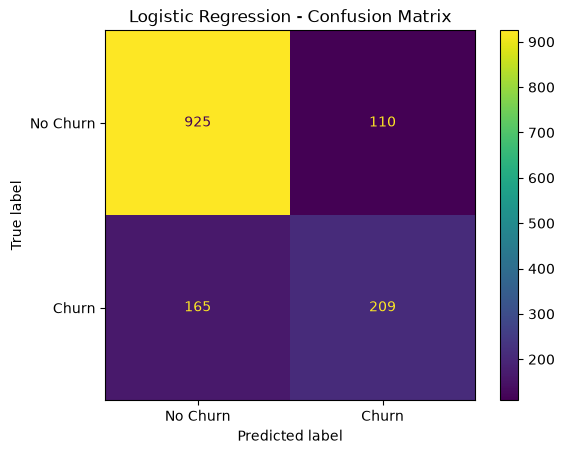


Decision Tree
[[913 122]
 [162 212]]


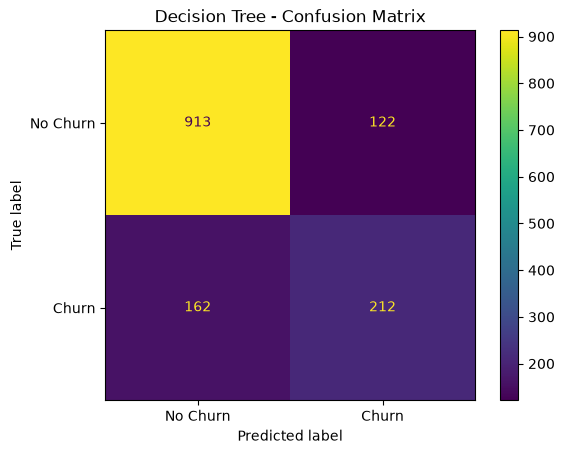


Random Forest
[[962  73]
 [216 158]]


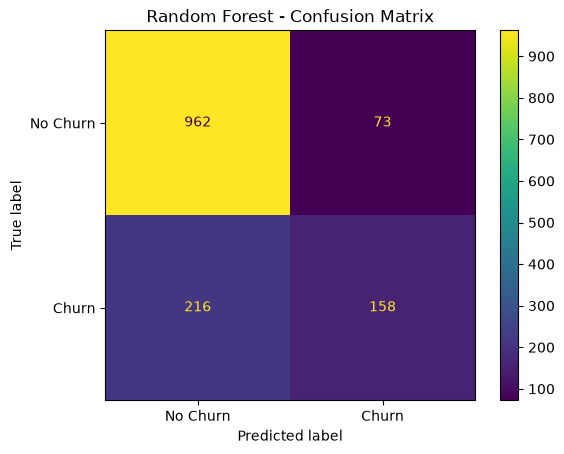


XGBoost
[[945  90]
 [186 188]]


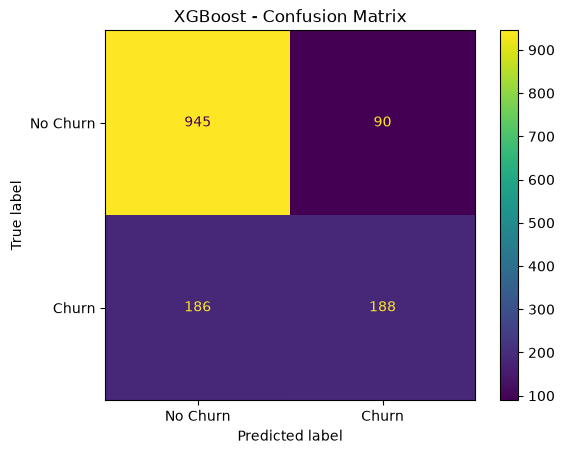

In [228]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_and_predictions = {
    "Logistic Regression": logistic_test_pred,
    "Decision Tree": decision_tree_test_pred,
    "Random Forest": random_forest_test_pred,
    "XGBoost": xgboost_test_pred
}

for model_name, predictions in models_and_predictions.items():
    cm = confusion_matrix(y_test, predictions)

    print(f"\n{model_name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

In [229]:
from sklearn.metrics import classification_report

models_and_predictions = {
    "Logistic Regression": logistic_test_pred,
    "Decision Tree": decision_tree_test_pred,
    "Random Forest": random_forest_test_pred,
    "XGBoost": xgboost_test_pred
}

for model_name, predictions in models_and_predictions.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["No Churn", "Churn"],
            digits=4
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn     0.8486    0.8937    0.8706      1035
       Churn     0.6552    0.5588    0.6032       374

    accuracy                         0.8048      1409
   macro avg     0.7519    0.7263    0.7369      1409
weighted avg     0.7973    0.8048    0.7996      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn     0.8493    0.8821    0.8654      1035
       Churn     0.6347    0.5668    0.5989       374

    accuracy                         0.7984      1409
   macro avg     0.7420    0.7245    0.7321      1409
weighted avg     0.7923    0.7984    0.7947      1409

Random Forest
              precision    recall  f1-score   support

    No Churn     0.8166    0.9295    0.8694      1035
       Churn     0.6840    0.4225    0.5223       374

    accuracy                         0.7949      1409
   macro avg     0.7503    0.6760    0.6959      1409
weighted avg     0.7814   

In [230]:
classification_summary = []

for model_name, predictions in models_and_predictions.items():
    report = classification_report(
        y_test,
        predictions,
        target_names=["No Churn", "Churn"],
        output_dict=True
    )

    classification_summary.append({
        "Model": model_name,
        "Churn Precision": report["Churn"]["precision"],
        "Churn Recall": report["Churn"]["recall"],
        "Churn F1-Score": report["Churn"]["f1-score"],
        "Churn Support": int(report["Churn"]["support"]),
        "Overall Accuracy": report["accuracy"]
    })

classification_summary_df = pd.DataFrame(classification_summary)

classification_summary_df.round(4)

,Model,Churn Precision,Churn Recall,Churn F1-Score,Churn Support,Overall Accuracy
0,Logistic Regression,0.6552,0.5588,0.6032,374,0.8048
1,Decision Tree,0.6347,0.5668,0.5989,374,0.7984
2,Random Forest,0.6840,0.4225,0.5223,374,0.7949
3,XGBoost,0.6763,0.5027,0.5767,374,0.8041


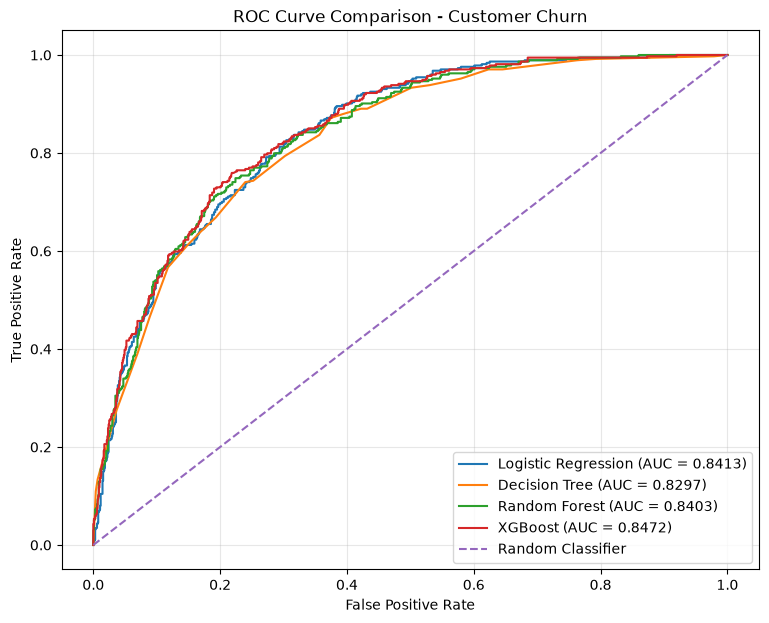

In [231]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models_and_probabilities = {
    "Logistic Regression": logistic_test_proba,
    "Decision Tree": decision_tree_test_proba,
    "Random Forest": random_forest_test_proba,
    "XGBoost": xgboost_test_proba
}

plt.figure(figsize=(9, 7))

for model_name, probabilities in models_and_probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Customer Churn")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

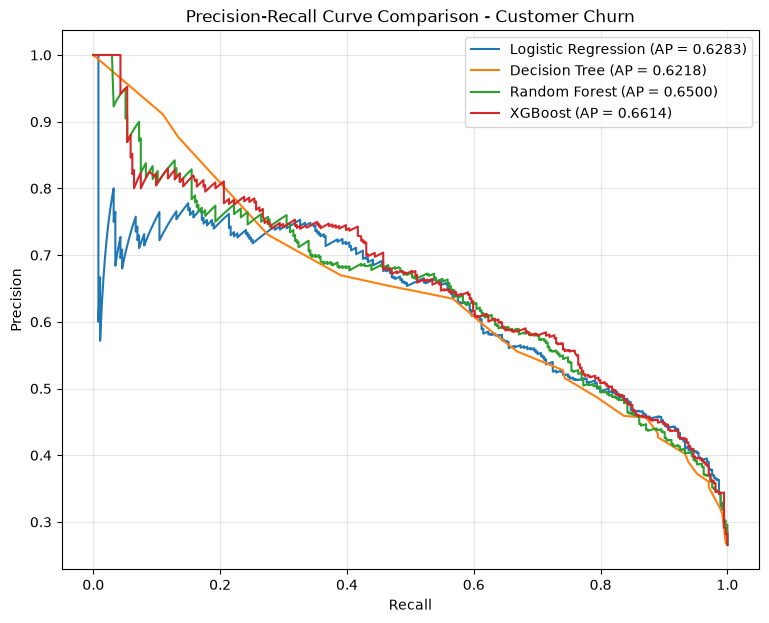

In [232]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for model_name, probabilities in models_and_probabilities.items():
    precision, recall, thresholds = precision_recall_curve(
        y_test,
        probabilities
    )

    average_precision = average_precision_score(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {average_precision:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison - Customer Churn")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [233]:
# Get the fitted preprocessing step and classifier
xgb_preprocessor = best_xgboost.named_steps["preprocessor"]
xgb_classifier = best_xgboost.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = xgb_preprocessor.get_feature_names_out()

# Get XGBoost feature importance
importance_values = xgb_classifier.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top 20 features
feature_importance_df.head(20)

,Feature,Importance
0,cat__Contract_Month-to-month,0.347668
1,cat__OnlineSecurity_No,0.101569
2,cat__TechSupport_No,0.084249
3,cat__InternetService_Fiber optic,0.078968
4,cat__InternetService_DSL,0.036052
5,num__tenure,0.031706
6,cat__Contract_Two year,0.026579
7,cat__PaymentMethod_Electronic check,0.025440
8,cat__PaperlessBilling_No,0.017313
9,cat__MultipleLines_Yes,0.016385


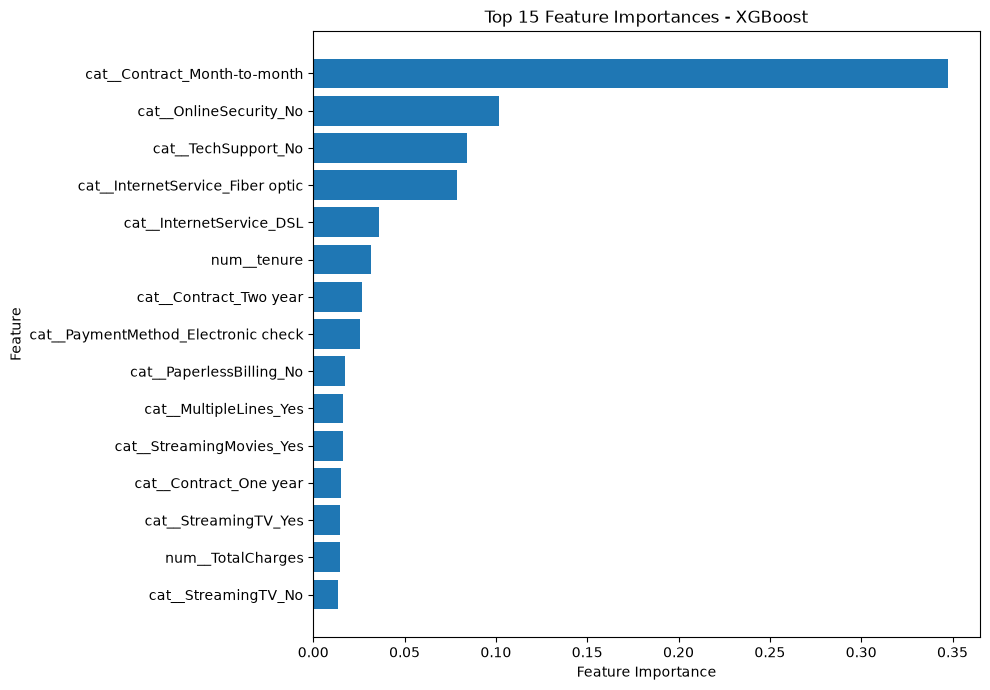

In [234]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")

plt.tight_layout()
plt.show()

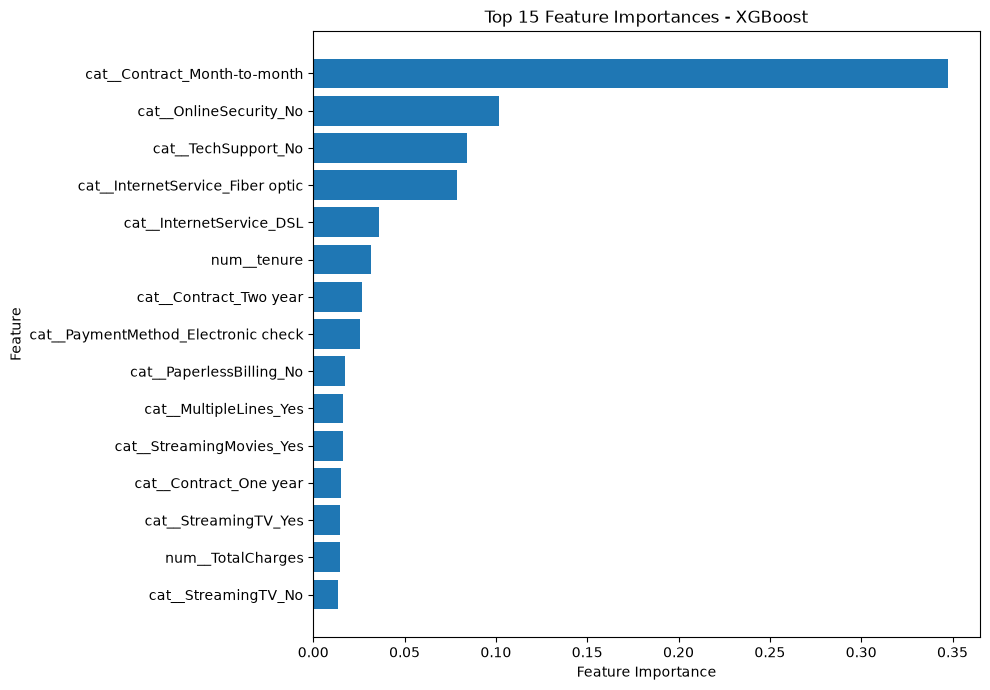

In [235]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")

plt.tight_layout()

plt.savefig(
    "../images/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [236]:
feature_importance_df.to_csv(
    "../reports/xgboost_feature_importance.csv",
    index=False
)

print("Feature importance data saved successfully.")

Feature importance data saved successfully.


In [237]:
# Create mapping from transformed features to original features

original_features = numeric_features + categorical_features

feature_mapping = []

for feature in feature_names:
    original_feature = None

    # Numerical features
    for col in numeric_features:
        if feature == f"num__{col}":
            original_feature = col
            break

    # Categorical features
    if original_feature is None:
        for col in categorical_features:
            if feature.startswith(f"cat__{col}_"):
                original_feature = col
                break

    feature_mapping.append(original_feature)

# Create DataFrame with original feature names
aggregated_importance_df = pd.DataFrame({
    "Original Feature": feature_mapping,
    "Importance": importance_values
})

# Aggregate importance for each original variable
aggregated_importance_df = (
    aggregated_importance_df
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

# Display results
aggregated_importance_df

,Original Feature,Importance
0,Contract,0.389598
1,InternetService,0.120176
2,OnlineSecurity,0.108961
3,TechSupport,0.087009
4,PaymentMethod,0.037734
5,tenure,0.031706
6,PaperlessBilling,0.029569
7,StreamingTV,0.028517
8,MultipleLines,0.028420
9,Dependents,0.023224


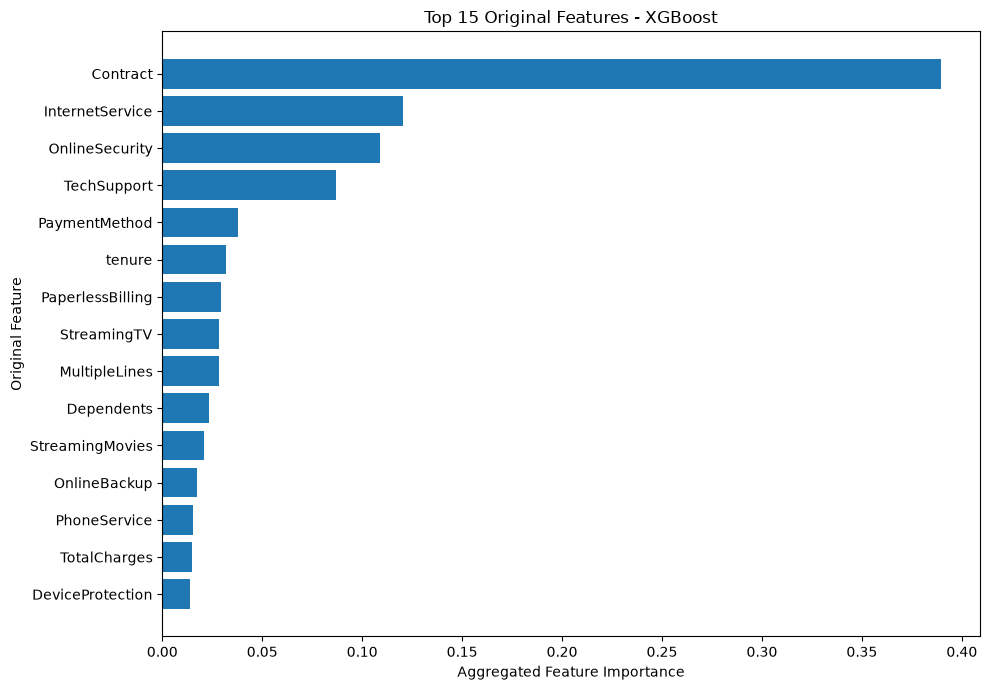

In [238]:
top_aggregated_features = aggregated_importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_aggregated_features["Original Feature"],
    top_aggregated_features["Importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Feature")
plt.title("Top 15 Original Features - XGBoost")

plt.tight_layout()
plt.show()

In [239]:
aggregated_importance_df.to_csv(
    "../reports/xgboost_aggregated_feature_importance.csv",
    index=False
)

print("Aggregated feature importance data saved successfully.")

Aggregated feature importance data saved successfully.


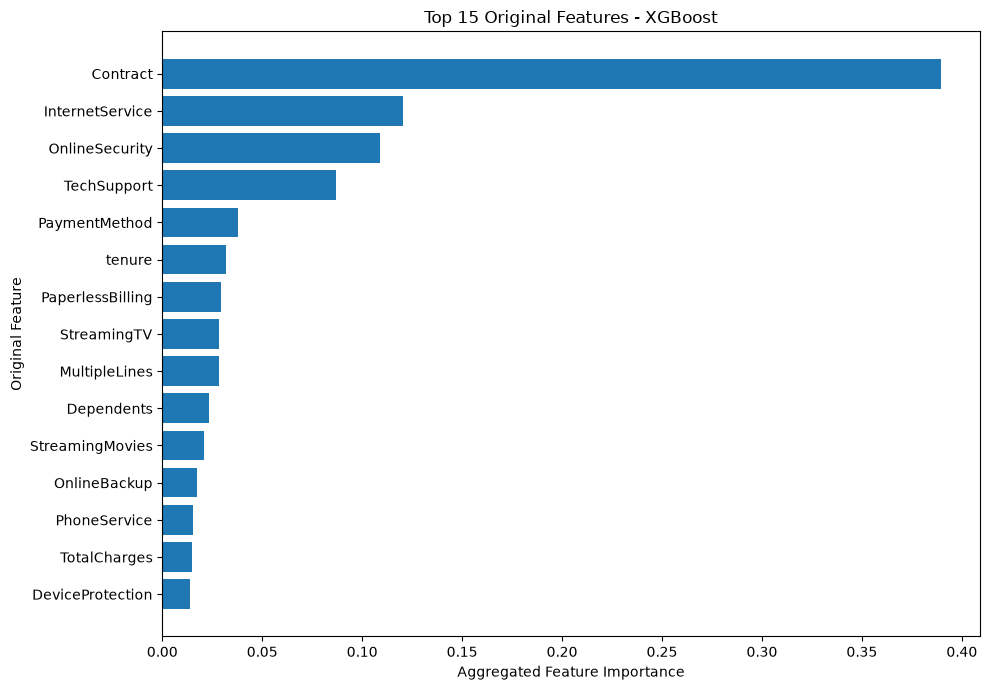

In [240]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_aggregated_features["Original Feature"],
    top_aggregated_features["Importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Feature")
plt.title("Top 15 Original Features - XGBoost")

plt.tight_layout()

plt.savefig(
    "../images/xgboost_aggregated_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [241]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold probability predictions
xgb_cv_probabilities = cross_val_predict(
    best_xgboost,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold probabilities generated.")
print("Number of predictions:", len(xgb_cv_probabilities))

Out-of-fold probabilities generated.
Number of predictions: 5634


In [242]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_train,
    xgb_cv_probabilities
)

# Calculate F1-score for each threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Find the threshold with the highest F1-score
best_threshold_index = f1_scores.argmax()

best_threshold = thresholds[best_threshold_index]
best_cv_precision = precision[best_threshold_index]
best_cv_recall = recall[best_threshold_index]
best_cv_f1 = f1_scores[best_threshold_index]

print("Best threshold:", round(best_threshold, 4))
print("Cross-validation Precision:", round(best_cv_precision, 4))
print("Cross-validation Recall:", round(best_cv_recall, 4))
print("Cross-validation F1-Score:", round(best_cv_f1, 4))

Best threshold: 0.338
Cross-validation Precision: 0.5727
Cross-validation Recall: 0.7271
Cross-validation F1-Score: 0.6407


In [243]:
# Apply the F1-optimized threshold to the test probabilities
xgb_test_pred_threshold = (
    xgboost_test_proba >= best_threshold
).astype(int)

# Evaluate the new threshold
threshold_precision = precision_score(
    y_test,
    xgb_test_pred_threshold
)

threshold_recall = recall_score(
    y_test,
    xgb_test_pred_threshold
)

threshold_f1 = f1_score(
    y_test,
    xgb_test_pred_threshold
)

threshold_accuracy = accuracy_score(
    y_test,
    xgb_test_pred_threshold

)

print("Threshold:", round(best_threshold, 4))
print("Test Accuracy:", round(threshold_accuracy, 4))
print("Test Precision:", round(threshold_precision, 4))
print("Test Recall:", round(threshold_recall, 4))
print("Test F1-Score:", round(threshold_f1, 4))

Threshold: 0.338
Test Accuracy: 0.7807
Test Precision: 0.5667
Test Recall: 0.738
Test F1-Score: 0.6411


XGBoost - Threshold 0.338
[[824 211]
 [ 98 276]]


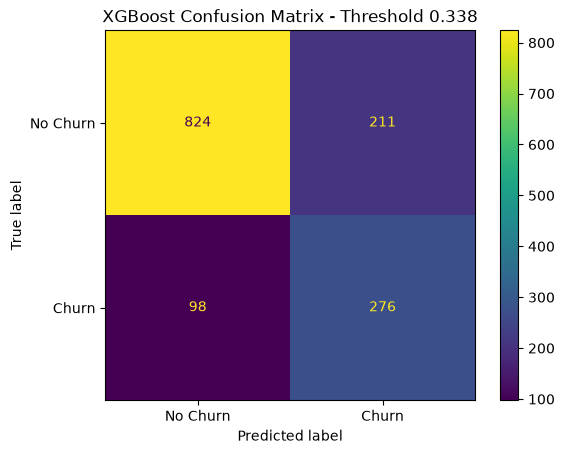

In [244]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_threshold = confusion_matrix(
    y_test,
    xgb_test_pred_threshold
)

print("XGBoost - Threshold 0.338")
print(cm_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix - Threshold 0.338")
plt.show()

In [245]:
threshold_comparison = pd.DataFrame([
    {
        "Threshold": 0.50,
        "Accuracy": accuracy_score(y_test, xgboost_test_pred),
        "Precision": precision_score(y_test, xgboost_test_pred),
        "Recall": recall_score(y_test, xgboost_test_pred),
        "F1-Score": f1_score(y_test, xgboost_test_pred)
    },
    {
        "Threshold": round(best_threshold, 3),
        "Accuracy": threshold_accuracy,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1-Score": threshold_f1
    }
])

threshold_comparison.round(4)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.500,0.8041,0.6763,0.5027,0.5767
1,0.338,0.7807,0.5667,0.7380,0.6411


In [246]:
threshold_comparison.to_csv(
    "../reports/xgboost_threshold_comparison.csv",
    index=False
)

print("Threshold comparison saved successfully.")

Threshold comparison saved successfully.


In [247]:
!pip install joblib


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [249]:
import joblib

joblib.dump(
    best_xgboost,
    "../models/xgboost_churn_pipeline.pkl"
)

print("XGBoost model pipeline saved successfully.")

XGBoost model pipeline saved successfully.


In [250]:
model.predict(customer_data)

NameError: name 'model' is not defined

In [251]:
import json

threshold_config = {
    "model": "XGBoost",
    "threshold": float(best_threshold),
    "selection_method": "F1-score optimization using out-of-fold training probabilities"
}

with open("../models/threshold_config.json", "w") as file:
    json.dump(threshold_config, file, indent=4)

print("Threshold configuration saved successfully.")
print(threshold_config)

Threshold configuration saved successfully.
{'model': 'XGBoost', 'threshold': 0.33801376819610596, 'selection_method': 'F1-score optimization using out-of-fold training probabilities'}


In [252]:
import joblib
import numpy as np

# Load the saved model pipeline
loaded_xgb_model = joblib.load(
    "../models/xgboost_churn_pipeline.pkl"
)

# Generate predictions using the loaded model
loaded_test_probabilities = loaded_xgb_model.predict_proba(
    X_test
)[:, 1]

# Compare with the original test probabilities
probabilities_match = np.allclose(
    xgboost_test_proba,
    loaded_test_probabilities
)

print("Saved model loaded successfully.")
print("Predictions match original model:", probabilities_match)

Saved model loaded successfully.
Predictions match original model: True


In [253]:
import json

# Load saved threshold configuration
with open("../models/threshold_config.json", "r") as file:
    loaded_threshold_config = json.load(file)

loaded_threshold = loaded_threshold_config["threshold"]

print("Saved threshold loaded successfully.")
print("Threshold:", loaded_threshold)
print("Matches original threshold:", np.isclose(
    best_threshold,
    loaded_threshold
))

Saved threshold loaded successfully.
Threshold: 0.33801376819610596
Matches original threshold: True


In [254]:
def predict_customer_churn(
    model,
    customer_data,
    threshold
):
    """
    Predict customer churn using the trained model pipeline.

    Parameters
    ----------
    model : fitted scikit-learn pipeline
        Trained preprocessing + XGBoost pipeline.

    customer_data : pandas.DataFrame
        Customer information in the same feature format used during training.

    threshold : float
        Probability threshold used to classify churn.

    Returns
    -------
    churn_probability : float
        Predicted probability of churn.

    churn_prediction : int
        1 = Churn
        0 = No Churn
    """

    # Generate churn probability
    churn_probability = model.predict_proba(
        customer_data
    )[:, 1][0]

    # Apply the selected threshold
    churn_prediction = int(
        churn_probability >= threshold
    )

    return churn_probability, churn_prediction

In [255]:
# Select one customer from the test set
sample_customer = X_test.iloc[[0]]

# Get the actual outcome
actual_outcome = y_test.iloc[0]

# Generate prediction
sample_probability, sample_prediction = predict_customer_churn(
    loaded_xgb_model,
    sample_customer,
    loaded_threshold
)

print("Customer Churn Prediction Test")
print("-" * 40)

print("Predicted Churn Probability:",
      round(sample_probability, 4))

print("Prediction:",
      "Churn" if sample_prediction == 1 else "No Churn")

print("Actual Outcome:",
      "Churn" if actual_outcome == 1 else "No Churn")

Customer Churn Prediction Test
----------------------------------------
Predicted Churn Probability: 0.0414
Prediction: No Churn
Actual Outcome: No Churn


In [256]:
# Select 10 customers from the test set
sample_customers = X_test.iloc[:10].copy()

# Generate churn probabilities
sample_probabilities = loaded_xgb_model.predict_proba(
    sample_customers
)[:, 1]

# Apply the saved threshold
sample_predictions = (
    sample_probabilities >= loaded_threshold
).astype(int)

# Create comparison table
batch_test_results = pd.DataFrame({
    "Churn Probability": sample_probabilities,
    "Predicted": [
        "Churn" if p == 1 else "No Churn"
        for p in sample_predictions
    ],
    "Actual": [
        "Churn" if y == 1 else "No Churn"
        for y in y_test.iloc[:10]
    ]
})

batch_test_results.round(4)

,Churn Probability,Predicted,Actual
0,0.0414,No Churn,No Churn
1,0.7664,Churn,No Churn
2,0.0662,No Churn,No Churn
3,0.3206,No Churn,No Churn
4,0.0238,No Churn,No Churn
5,0.5662,Churn,No Churn
6,0.4464,Churn,No Churn
7,0.1073,No Churn,No Churn
8,0.0145,No Churn,No Churn
9,0.3527,Churn,Churn
